Block 1: Import & Konfiguration

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Konfiguration
data_path = 'mnist_train.csv'
image_size = 28
num_classes = 10
batch_size = 128  # Größere Batches für schnelleres Training
learning_rate = 0.01  # Höhere Learning Rate
num_epochs = 3  # Weniger Epochen
train_split = 0.8


Block 2: Daten laden

In [36]:
data = pd.read_csv(data_path)

print(f"Datensatz-Form: {data.shape}")
print(f"Label-Verteilung:\n{data['label'].value_counts().sort_index()}")

# Labels und Pixel trennen
labels = data.iloc[:, 0].values  # Erste Spalte = Labels
pixels = data.iloc[:, 1:].values  # Rest = Pixel-Daten

print(f"Anzahl Samples: {len(labels)}")
print(f"Pixel pro Bild: {pixels.shape[1]}")

Datensatz-Form: (60000, 785)
Label-Verteilung:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64
Anzahl Samples: 60000
Pixel pro Bild: 784


Block 3: Preprocessing & Umwandlung in Tensoren

Bilder Shape: torch.Size([60000, 1, 28, 28])
Labels Shape: torch.Size([60000])


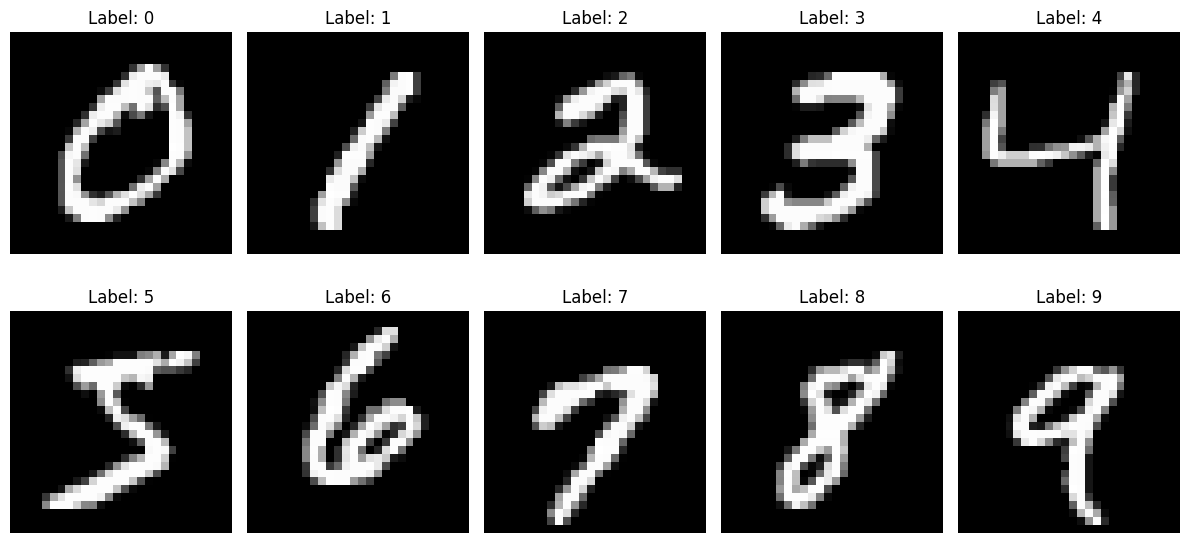

In [37]:
images = pixels.reshape(-1, 1, image_size, image_size).astype(np.float32) / 255.0
labels_tensor = labels.astype(np.int64)

# Zu PyTorch Tensoren konvertieren
X = torch.FloatTensor(images)
y = torch.LongTensor(labels_tensor)

print(f"Bilder Shape: {X.shape}")
print(f"Labels Shape: {y.shape}")

# Beispiel-Bilder anzeigen
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row, col = i // 5, i % 5
    # Erstes Bild mit diesem Label finden
    idx = np.where(labels == i)[0][0]
    image = X[idx, 0].numpy()
    
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {i}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Block 4: Dataset und DataLoader erstellen

In [38]:
# Batch-Größe festlegen
dataset = TensorDataset(X, y)

# Train/Test Split
train_size = int(train_split * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoader erstellen
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training-Samples: {len(train_dataset)}")
print(f"Test-Samples: {len(test_dataset)}")
print(f"Training-Batches: {len(train_loader)}")
print(f"Test-Batches: {len(test_loader)}")

Training-Samples: 48000
Test-Samples: 12000
Training-Batches: 375
Test-Batches: 94


Block 5: CNN-Modell definieren

In [39]:
model = nn.Sequential(
    # Erster Convolutional Block
    nn.Conv2d(1, 32, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    
    # Zweiter Convolutional Block
    nn.Conv2d(32, 64, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    
    # Fully Connected Layers
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.BatchNorm1d(128),  # Batch Normalization
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, num_classes)
)

# Parameter zählen
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Anzahl trainierbarer Parameter: {total_params:,}")

Anzahl trainierbarer Parameter: 455,178


Block 6: Training setup

In [40]:
# Loss und Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Listen für Tracking
train_losses = []
train_accuracies = []

print("Training-Setup abgeschlossen!")

Training-Setup abgeschlossen!


Block 7: Modell trainieren

In [41]:
print("Starte Training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistiken
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        
        # Progress anzeigen (alle 50 Batches)
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, '
                  f'Loss: {loss.item():.4f}')
    
    # Epochen-Statistiken berechnen
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100. * correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    print(f'Epoch {epoch+1} abgeschlossen - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print("Training abgeschlossen!")

Starte Training...
Epoch 1/3, Batch 0/375, Loss: 2.3902
Epoch 1/3, Batch 100/375, Loss: 0.0917
Epoch 1/3, Batch 200/375, Loss: 0.0561
Epoch 1/3, Batch 300/375, Loss: 0.0492
Epoch 1 abgeschlossen - Loss: 0.1246, Accuracy: 96.18%
Epoch 2/3, Batch 0/375, Loss: 0.0181
Epoch 2/3, Batch 100/375, Loss: 0.0529
Epoch 2/3, Batch 200/375, Loss: 0.1198
Epoch 2/3, Batch 300/375, Loss: 0.0486
Epoch 2 abgeschlossen - Loss: 0.0471, Accuracy: 98.59%
Epoch 3/3, Batch 0/375, Loss: 0.0244
Epoch 3/3, Batch 100/375, Loss: 0.0284
Epoch 3/3, Batch 200/375, Loss: 0.0522
Epoch 3/3, Batch 300/375, Loss: 0.0353
Epoch 3 abgeschlossen - Loss: 0.0322, Accuracy: 98.98%
Training abgeschlossen!


Block 8: Test & Evaluation

In [42]:
print("Starte Test...")

model.eval()
test_loss = 0.0
correct = 0
total = 0
all_predictions = []
all_targets = []

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        #data, target = data.to(device), target.to(device)
        
        outputs = model(data)
        test_loss += criterion(outputs, target).item()
        
        _, predicted = torch.max(outputs, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        
        # Für detaillierte Analyse sammeln
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        
        #if batch_idx % 20 == 0:
        #    print(f'Test Batch {batch_idx}/{len(test_loader)}')

# Finale Ergebnisse
test_loss = test_loss / len(test_loader)
test_accuracy = 100. * correct / total

print(f'\nTEST-ERGEBNISSE:')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}% ({correct}/{total})')

Starte Test...

TEST-ERGEBNISSE:
Test Loss: 0.0481
Test Accuracy: 98.54% (11825/12000)


Block 9: Ergebnisse visualisieren & Beispiel vorhersagen

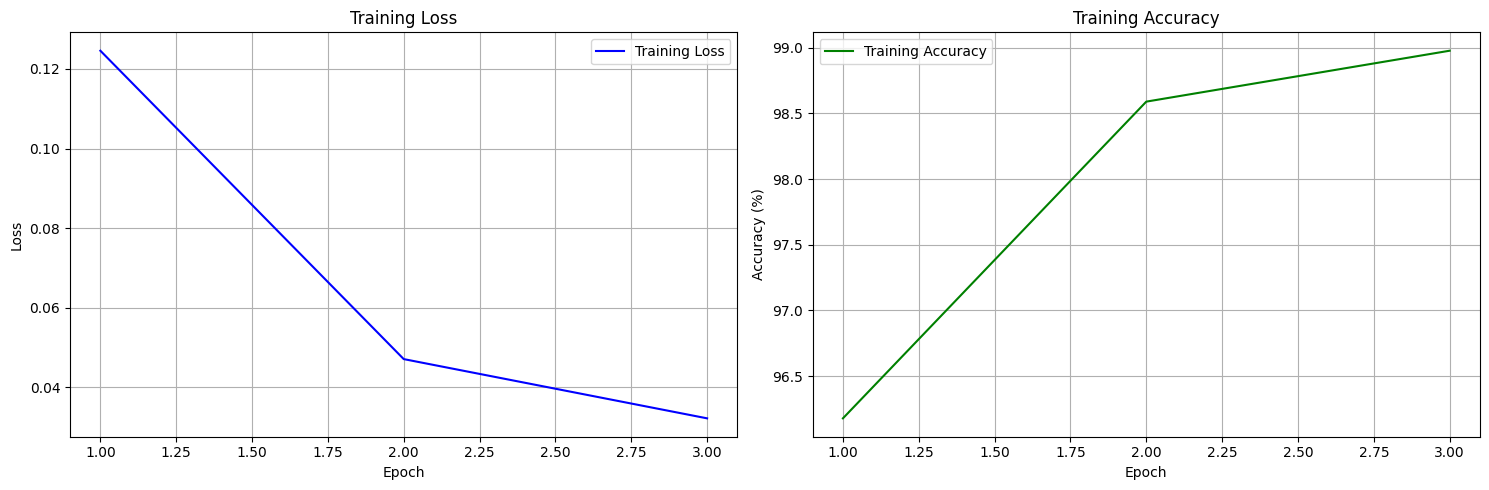

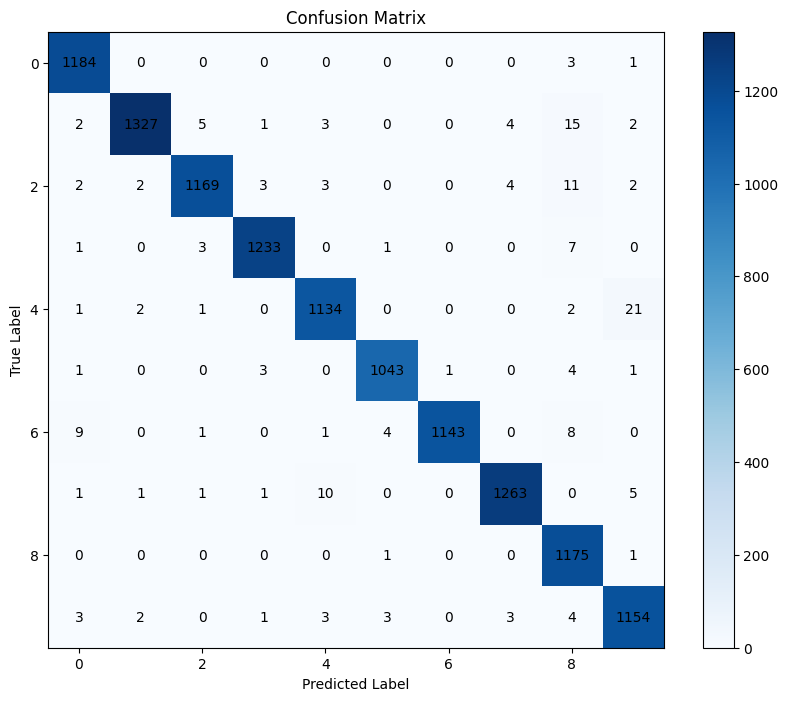

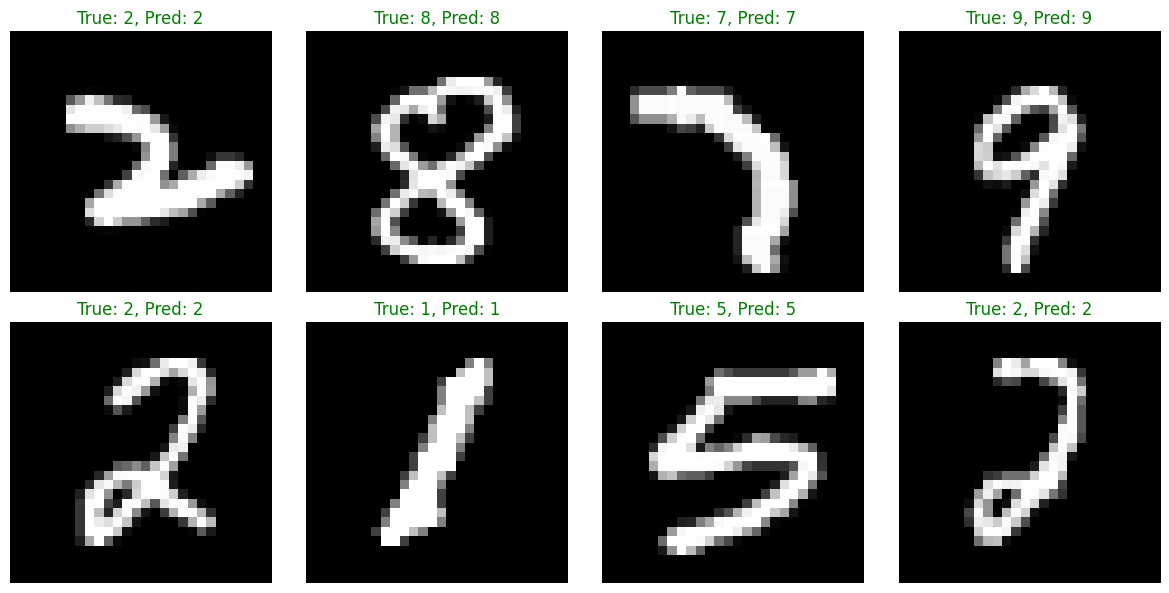

In [43]:
# Training History plotten
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Plot
ax1.plot(range(1, len(train_losses)+1), train_losses, 'b-', label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Plot
ax2.plot(range(1, len(train_accuracies)+1), train_accuracies, 'g-', label='Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_targets, all_predictions)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Zahlen in die Matrix eintragen
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.show()

# Beispiel-Vorhersagen anzeigen
model.eval()
with torch.no_grad():
    # Ersten Test-Batch nehmen
    test_data, test_targets = next(iter(test_loader))
    #test_data = test_data.to(device)
    test_outputs = model(test_data)
    _, test_predicted = torch.max(test_outputs, 1)
    
    # 8 Beispiele zeigen
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(8):
        row, col = i // 4, i % 4
        
        image = test_data[i, 0].cpu().numpy()
        true_label = test_targets[i].item()
        pred_label = test_predicted[i].cpu().item()
        
        axes[row, col].imshow(image, cmap='gray')
        color = 'green' if true_label == pred_label else 'red'
        axes[row, col].set_title(f'True: {true_label}, Pred: {pred_label}', color=color)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()